# Bluestock Mutual Fund Analytics

## 03 - Exploratory Data Analysis (EDA)

This notebook performs exploratory analysis of the mutual fund datasets.
It examines fund-house AUM, scheme performance, SIP inflows, category
inflows, and NAV history through descriptive statistics and visualisations.

The objective is to identify patterns, trends, relationships, and
business insights from the available mutual fund data.

In [39]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print("Processed folder:", PROCESSED_DIR)
print("Folder exists:", PROCESSED_DIR.exists())

Processed folder: c:\Users\Farhan\bluestock_mf_capstone\data\processed
Folder exists: True


In [40]:
def find_dataset(keyword):
    files = list(PROCESSED_DIR.glob(f"*{keyword}*.csv"))
    
    if not files:
        raise FileNotFoundError(
            f"Dataset not found for keyword: {keyword}"
        )
    
    return files[0]


fund_master_file = find_dataset("fund_master")
scheme_performance_file = find_dataset("scheme_performance")
aum_file = find_dataset("aum_by_fund_house")
sip_file = find_dataset("monthly_sip_inflows")
category_file = find_dataset("category_inflows")
nav_file = find_dataset("nav_history")

print("Datasets located successfully.")

Datasets located successfully.


In [41]:
fund_master = pd.read_csv(fund_master_file)
scheme_performance = pd.read_csv(scheme_performance_file)
aum = pd.read_csv(aum_file)
sip = pd.read_csv(sip_file)
category_inflows = pd.read_csv(category_file)
nav_history = pd.read_csv(nav_file)

print("Fund Master:", fund_master.shape)
print("Scheme Performance:", scheme_performance.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Category Inflows:", category_inflows.shape)
print("NAV History:", nav_history.shape)

Fund Master: (40, 15)
Scheme Performance: (40, 19)
AUM: (90, 5)
SIP: (48, 6)
Category Inflows: (144, 3)
NAV History: (46000, 3)


In [42]:
aum["date"] = pd.to_datetime(aum["date"], errors="coerce")

latest_aum = (
    aum.sort_values("date")
       .groupby("fund_house")
       .tail(1)
       .sort_values("aum_crore", ascending=False)
)

display(
    latest_aum[
        ["fund_house", "aum_crore", "num_schemes"]
    ].head(10)
)

,fund_house,aum_crore,num_schemes
80,SBI Mutual Fund,1250000,186
81,ICICI Prudential MF,1074000,216
82,HDFC Mutual Fund,930000,195
83,Nippon India MF,700000,177
84,Kotak Mahindra MF,580000,168
85,Aditya Birla Sun Life MF,460000,199
87,UTI Mutual Fund,410000,142
86,Axis Mutual Fund,350000,95
88,Mirae Asset MF,290000,56
89,DSP Mutual Fund,230000,88


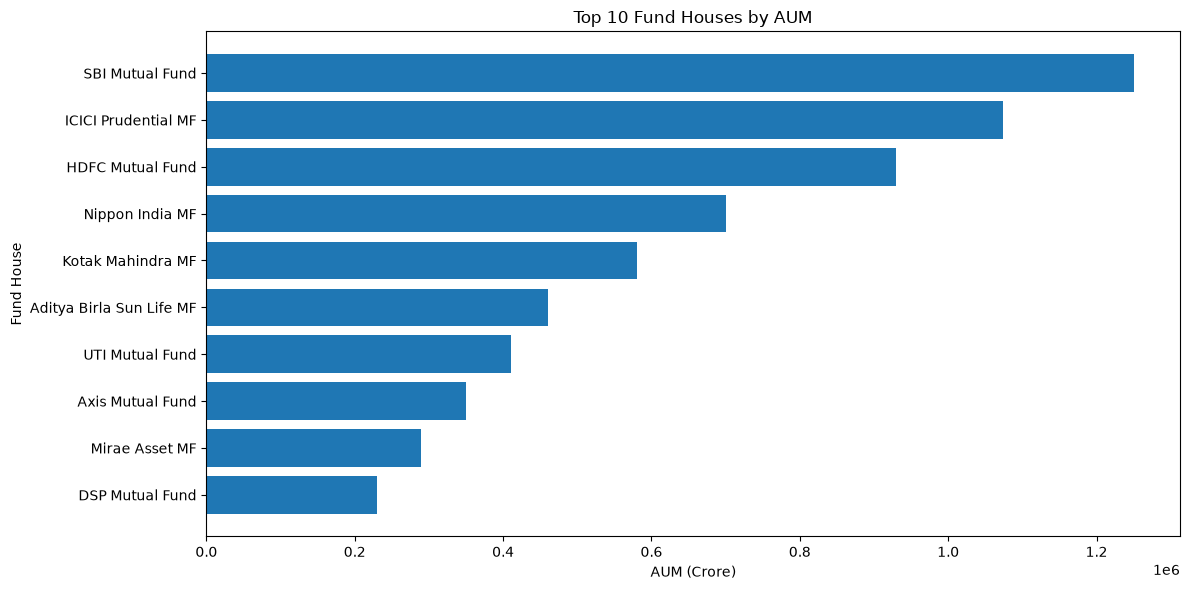

In [43]:
plt.figure(figsize=(12, 6))

plot_data = latest_aum.head(10).sort_values("aum_crore")

plt.barh(
    plot_data["fund_house"],
    plot_data["aum_crore"]
)

plt.xlabel("AUM (Crore)")
plt.ylabel("Fund House")
plt.title("Top 10 Fund Houses by AUM")

plt.tight_layout()
plt.show()

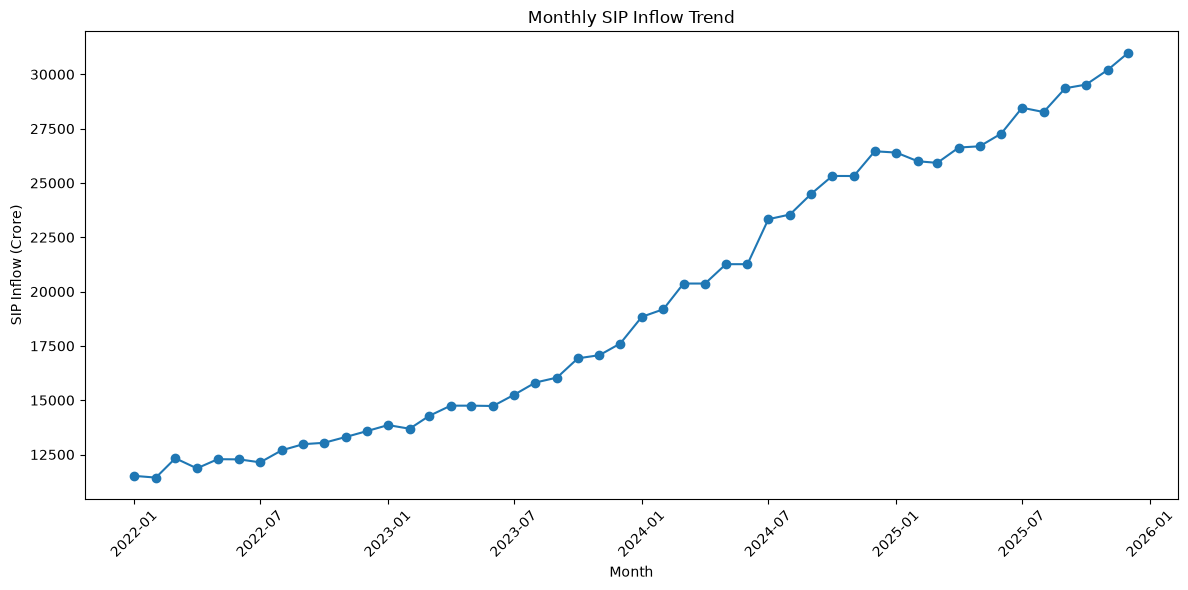

In [44]:
sip["month"] = pd.to_datetime(
    sip["month"],
    errors="coerce"
)

plt.figure(figsize=(12, 6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.title("Monthly SIP Inflow Trend")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [45]:
category_inflows["month"] = pd.to_datetime(
    category_inflows["month"],
    errors="coerce"
)

category_summary = (
    category_inflows
    .groupby("category")["net_inflow_crore"]
    .sum()
    .sort_values(ascending=False)
)

display(category_summary)

category
Liquid               451275.0
Sectoral/Thematic    103829.0
Flexi Cap             63989.0
Large & Mid Cap       57752.0
Short Duration        55530.0
Mid Cap               55312.0
Small Cap             46596.0
Hybrid                38868.0
Large Cap             25633.0
Value/Contra          16980.0
Gilt                  10395.0
ELSS                   6080.0
Name: net_inflow_crore, dtype: float64

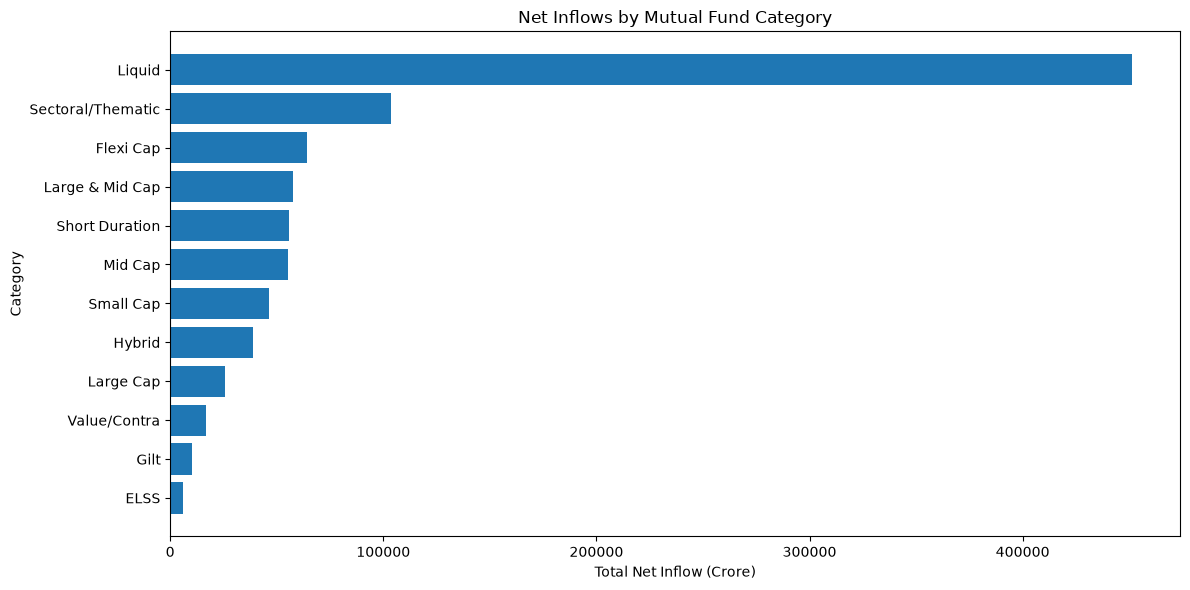

In [46]:
plt.figure(figsize=(12, 6))

plot_data = category_summary.sort_values()

plt.barh(
    plot_data.index,
    plot_data.values
)

plt.xlabel("Total Net Inflow (Crore)")
plt.ylabel("Category")
plt.title("Net Inflows by Mutual Fund Category")

plt.tight_layout()
plt.show()

In [47]:
performance = scheme_performance[
    [
        "scheme_name",
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct",
        "sharpe_ratio"
    ]
].copy()

performance = performance.sort_values(
    "return_3yr_pct",
    ascending=False
)

display(performance.head(10))

,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct,sharpe_ratio
2,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67,0.94
3,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82,0.93
29,ABSL Small Cap Fund - Regular - Growth,24.93,22.38,23.80,0.90
27,Axis Small Cap Fund - Regular - Growth,21.97,20.98,22.62,0.84
17,Nippon India Small Cap Fund - Regular - Growth,21.30,20.15,21.88,0.81
39,DSP Small Cap Fund - Regular - Growth,20.20,20.08,20.61,0.80
21,Kotak Emerging Equity Fund - Regular - Growth,17.12,18.23,17.75,0.96
12,ICICI Pru Midcap Fund - Regular - Growth,14.02,18.08,17.55,0.95
38,DSP Midcap Fund - Regular - Growth,14.12,17.16,19.00,0.90
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,15.43,16.58,17.69,0.87


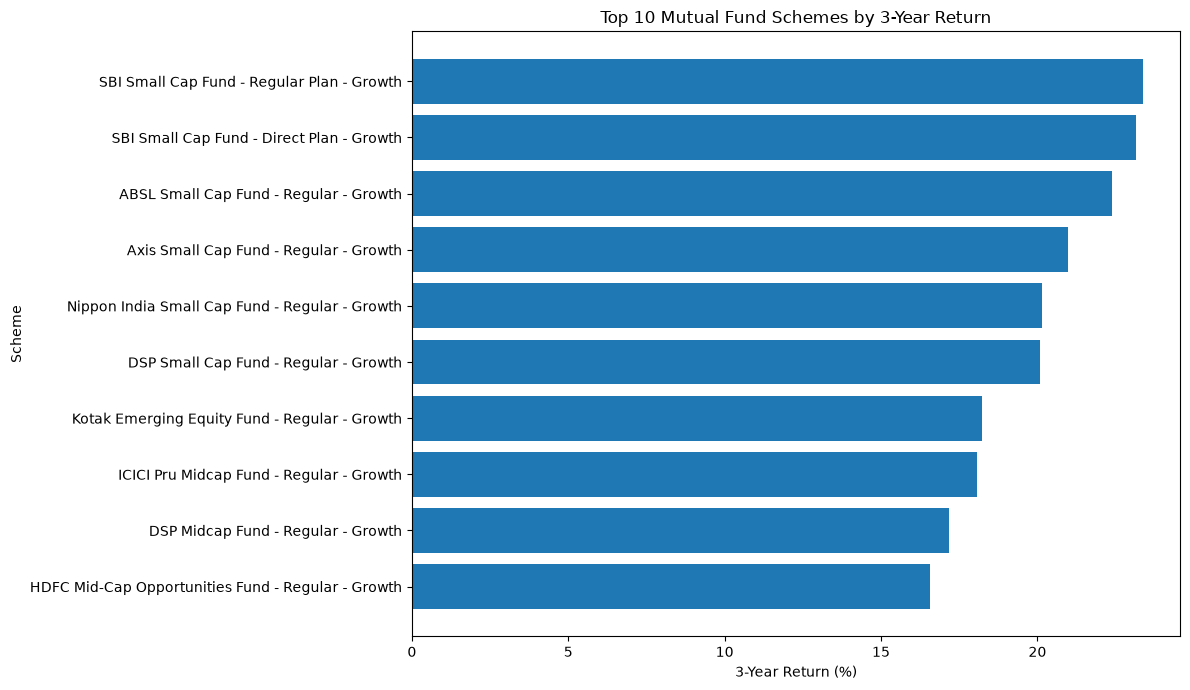

In [48]:
top10 = performance.head(10).sort_values(
    "return_3yr_pct"
)

plt.figure(figsize=(12, 7))

plt.barh(
    top10["scheme_name"],
    top10["return_3yr_pct"]
)

plt.xlabel("3-Year Return (%)")
plt.ylabel("Scheme")
plt.title("Top 10 Mutual Fund Schemes by 3-Year Return")

plt.tight_layout()
plt.show()

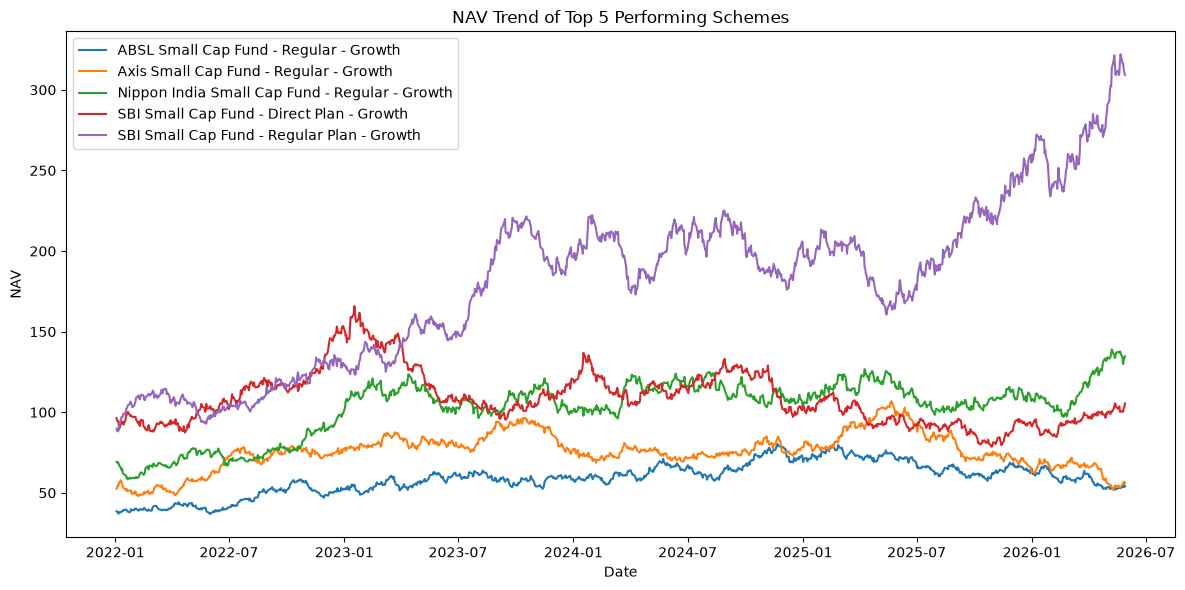

In [49]:
nav_history["date"] = pd.to_datetime(
    nav_history["date"],
    errors="coerce"
)

# Top 5 schemes based on 3-year return
top5_schemes = performance.head(5)[
    ["scheme_name"]
].merge(
    scheme_performance[
        ["scheme_name", "amfi_code"]
    ],
    on="scheme_name",
    how="left"
)

nav_plot = nav_history[
    nav_history["amfi_code"].isin(
        top5_schemes["amfi_code"]
    )
].copy()

nav_plot = nav_plot.merge(
    top5_schemes,
    on="amfi_code",
    how="left"
)

plt.figure(figsize=(12, 6))

for scheme_name, group in nav_plot.groupby("scheme_name"):
    group = group.sort_values("date")

    plt.plot(
        group["date"],
        group["nav"],
        label=scheme_name
    )

plt.xlabel("Date")
plt.ylabel("NAV")
plt.title("NAV Trend of Top 5 Performing Schemes")
plt.legend()

plt.tight_layout()
plt.show()

## EDA Business Insights

### Fund House AUM
The AUM distribution shows differences in the scale of assets managed by
different fund houses. Larger fund houses manage substantially higher assets
compared with smaller players.

### SIP Inflows
Monthly SIP inflows provide an indication of investor participation and
systematic investment activity over time. Changes in the trend can indicate
changes in investor sentiment and market participation.

### Category Inflows
Net inflows vary across mutual fund categories. Categories with stronger
positive inflows may indicate relatively higher investor preference during
the observation period.

### Scheme Performance
3-year returns help compare medium-term performance across schemes.
However, returns should not be evaluated in isolation and should be considered
alongside risk metrics such as Sharpe ratio, volatility, and maximum drawdown.

### NAV Trend
NAV movements reflect changes in the underlying value of the mutual fund
portfolio over time. Comparing NAV trends across schemes helps identify
relative growth patterns.

In [50]:
metrics = scheme_performance[
    [
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct",
        "alpha",
        "beta",
        "sharpe_ratio",
        "sortino_ratio",
        "std_dev_ann_pct",
        "max_drawdown_pct"
    ]
].copy()

correlation = metrics.corr()

display(correlation.round(2))

,return_1yr_pct,return_3yr_pct,return_5yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct
return_1yr_pct,1.00,0.91,0.88,-0.20,0.69,-0.51,-0.52,0.91,-0.46
return_3yr_pct,0.91,1.00,0.93,-0.23,0.73,-0.52,-0.53,0.96,-0.48
return_5yr_pct,0.88,0.93,1.00,-0.23,0.70,-0.48,-0.48,0.94,-0.51
alpha,-0.20,-0.23,-0.23,1.00,-0.24,0.24,0.22,-0.30,0.16
beta,0.69,0.73,0.70,-0.24,1.00,-0.71,-0.71,0.81,-0.78
sharpe_ratio,-0.51,-0.52,-0.48,0.24,-0.71,1.00,0.99,-0.68,0.58
sortino_ratio,-0.52,-0.53,-0.48,0.22,-0.71,0.99,1.00,-0.69,0.59
std_dev_ann_pct,0.91,0.96,0.94,-0.30,0.81,-0.68,-0.69,1.00,-0.59
max_drawdown_pct,-0.46,-0.48,-0.51,0.16,-0.78,0.58,0.59,-0.59,1.00


## EDA Conclusion

The exploratory analysis provides an overview of the mutual fund ecosystem
across fund houses, investor flows, scheme performance, and NAV movements.

Key findings include:

- Fund-house AUM varies significantly across asset managers.
- SIP inflows show changes in systematic investment activity over time.
- Mutual fund categories experience different levels of net investor inflows.
- Medium-term scheme returns vary considerably across funds.
- Risk-adjusted measures such as Sharpe ratio and volatility are important
  when comparing schemes with different return profiles.
- NAV trends provide a historical view of scheme value movements.

These findings provide the foundation for detailed performance analytics,
risk analysis, and recommendation modelling in the next stages.